## Importe

In diesem Abschnitt werden die notwendigen Bibliotheken importiert, die für die Datenanalyse und Visualisierung verwendet werden.

In [50]:
import pandas as pd
import numpy as np
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

## Einlesen der CSV-Dateien

In diesem Abschnitt werden die CSV-Dateien eingelesen, die die Gesundheitsindikatoren und Diabetes-Daten enthalten. Diese Daten werden in Pandas DataFrames geladen, um sie für die Analyse und Visualisierung vorzubereiten.

Die folgenden CSV-Dateien werden eingelesen:
- `diabetes_012_health_indicators_BRFSS2015.csv`: Enthält Daten zu verschiedenen Gesundheitsindikatoren und dem Diabetes-Status (0, 1 oder 2).
- `diabetes_binary_health_indicators_BRFSS2015.csv`: Enthält Daten zu verschiedenen Gesundheitsindikatoren und einem binären Diabetes-Status (0 oder 1).
- `diabetes_binary_5050split_health_indicators_BRFSS2015.csv`: Enthält Daten zu verschiedenen Gesundheitsindikatoren und einem binären Diabetes-Status (0 oder 1), wobei die Daten gleichmäßig aufgeteilt sind.

Im weiteren Verlauf des Codes wird nur die `diabetes_012_health_indicators_BRFSS2015.csv` genutzt, da dies der Grunddatensatz ist und die anderen zwei CSV Datein auf diesen aufbauen und die gleichen Daten enthalten.


In [51]:
df_diabetes_012 = pd.read_csv('dataset/diabetes_012_health_indicators_BRFSS2015.csv')
df_diabetes_binary = pd.read_csv('dataset/diabetes_binary_health_indicators_BRFSS2015.csv')
df_diabetes_binary_50_50 = pd.read_csv('dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

## Form des Datensatzes `df_diabetes_012`

In diesem Abschnitt wird die Form des Datensatzes `df_diabetes_012` dargestellt. Die Form eines DataFrames gibt die Anzahl der Zeilen und Spalten an und ist ein wichtiger erster Schritt, um ein Gefühl für die Größe und Struktur der Daten zu bekommen.

Die Form des Datensatzes `df_diabetes_012` ist wie folgt:

In [ ]:
print(f"Shape df_diabetes_012: {df_diabetes_012.shape}")

Shape df_diabetes_012: (253680, 22)


## Spalten der Datensätze

In diesem Abschnitt werden die Spaltennamen der eingelesenen Datensätze angezeigt. Dies gibt einen Überblick über die verschiedenen Gesundheitsindikatoren und Merkmale, die in den Datensätzen enthalten sind.

### Spaltennamen für alle CSV Dateien mit Skalenniveau und Typ

- **Diabetes_012**: Diabetes-Status (0, 1 oder 2), Ordinal, Output
- **HighBP**: Bluthochdruck (0 oder 1), Nominal (binär), Input
- **HighChol**: Hoher Cholesterinspiegel (0 oder 1), Nominal (binär), Input
- **CholCheck**: Cholesterinüberprüfung (0 oder 1), Nominal (binär), Input
- **BMI**: Body-Mass-Index, Kardinal, Input
- **Smoker**: Raucherstatus (0 oder 1), Nominal (binär), Input
- **Stroke**: Schlaganfall (0 oder 1), Nominal (binär), Input
- **HeartDiseaseorAttack**: Herzkrankheit oder Herzinfarkt (0 oder 1), Nominal (binär), Input
- **PhysActivity**: Körperliche Aktivität (0 oder 1), Nominal (binär), Input
- **Fruits**: Obstkonsum (0 oder 1), Nominal (binär), Input
- **Veggies**: Gemüsekonsum (0 oder 1), Nominal (binär), Input
- **HvyAlcoholConsump**: Hoher Alkoholkonsum (0 oder 1), Nominal (binär), Input
- **AnyHealthcare**: Zugang zu Gesundheitsversorgung (0 oder 1), Nominal (binär), Input
- **NoDocbcCost**: Kein Arztbesuch wegen Kosten (0 oder 1), Nominal (binär), Input
- **genhlth**: allgemeiner gesundheitszustand (1 bis 5), Ordinal, Input
- **menthlth**: mentale gesundheit (anzahl der tage), Kardinal, Input
- **physhlth**: körperliche gesundheit (anzahl der tage), Kardinal, Input
- **diffwalk**: schwierigkeiten beim gehen (0 oder 1), Nominal (binär), Input
- **sex**: geschlecht (0 oder 1), Nominal (binär), Input
- **age**: alter (in jahren)Ordinal, Input
- **education**: bildungsstand (1 bis 6)Ordinal, Input
- **income**: einkommen (1 bis 8)Ordinal, Input


In [53]:
print(f"Columns df_diabetes_012: {df_diabetes_012.columns}")

Columns df_diabetes_012: Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')


## Statistische Beschreibung der Datensätze

In diesem Abschnitt wird die statistische Beschreibung des Datensatzes `df_diabetes_012` dargestellt. Diese Beschreibung umfasst Kennzahlen wie Mittelwert, Standardabweichung, Minimum, Maximum und Perzentile für jede Spalte der Datensätze.

### Statistische Beschreibung für `df_diabetes_012`

Die statistische Beschreibung des Datensatzes `df_diabetes_012` zeigt die Verteilung der verschiedenen Gesundheitsindikatoren und Merkmale:

In [54]:
display(df_diabetes_012.describe().T)

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


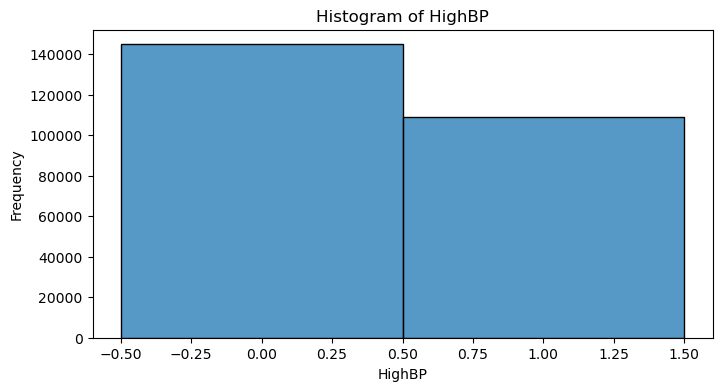

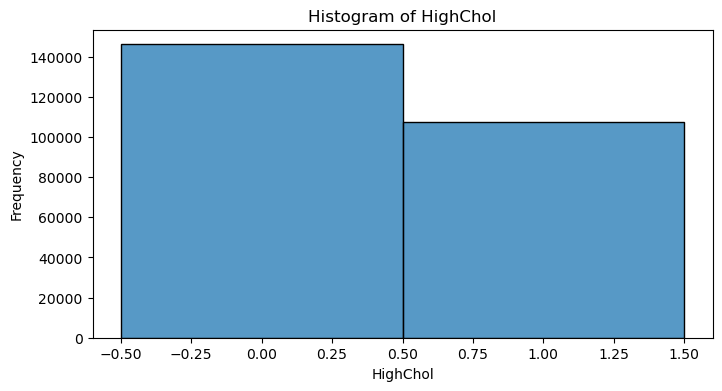

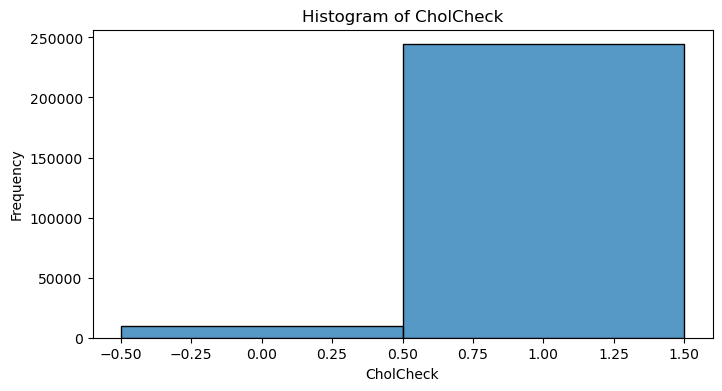

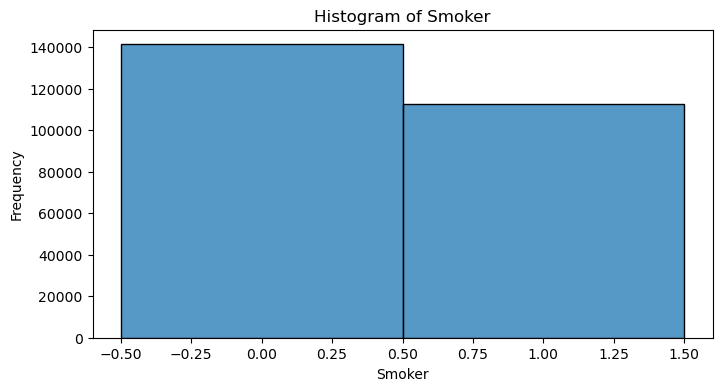

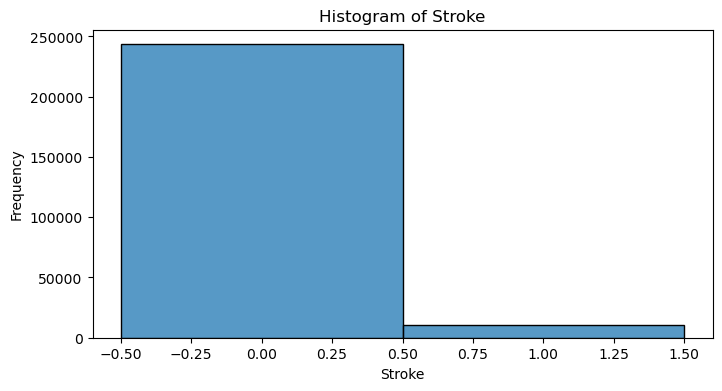

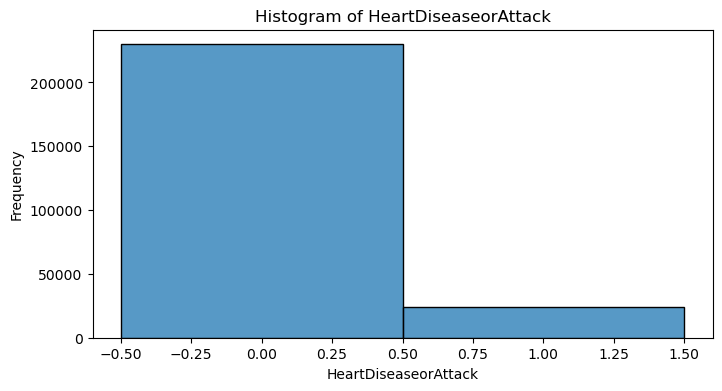

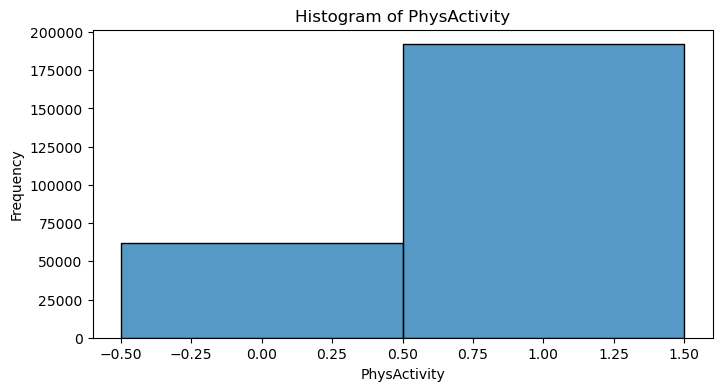

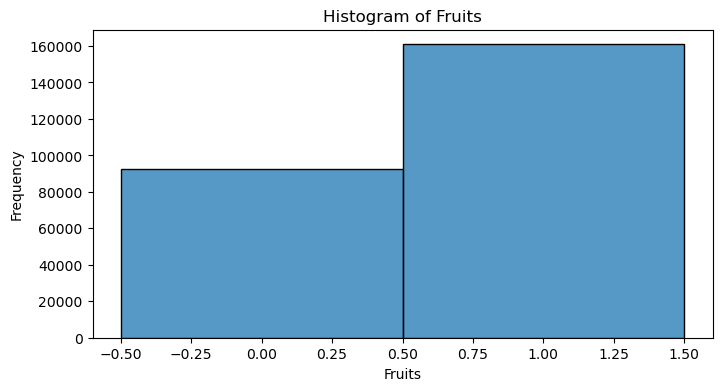

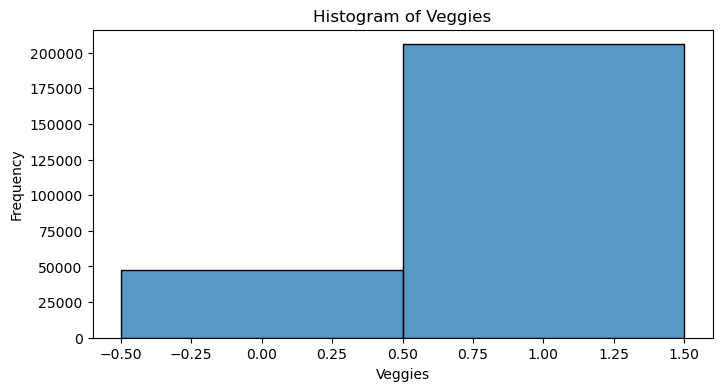

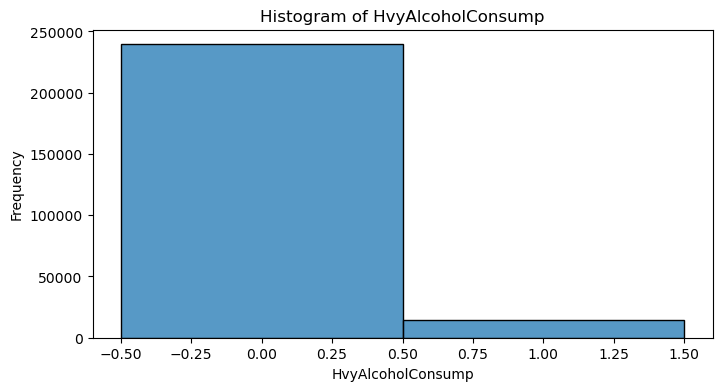

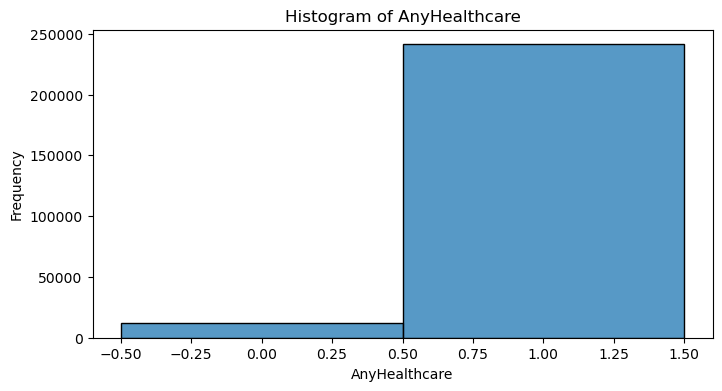

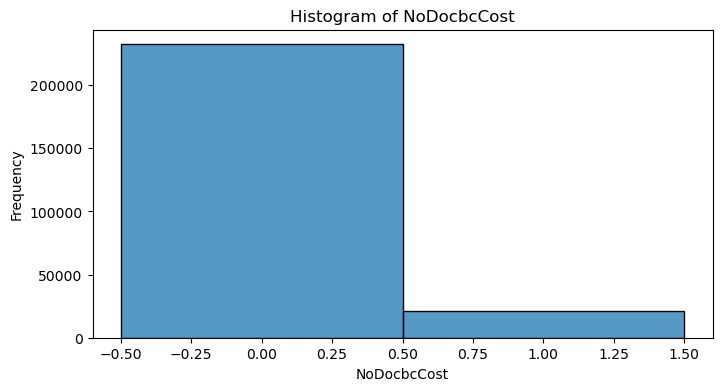

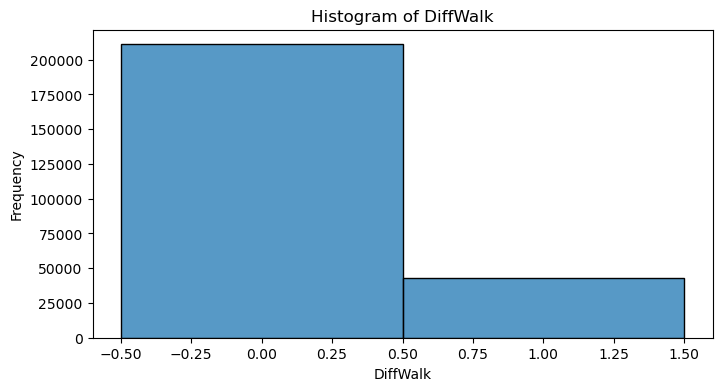

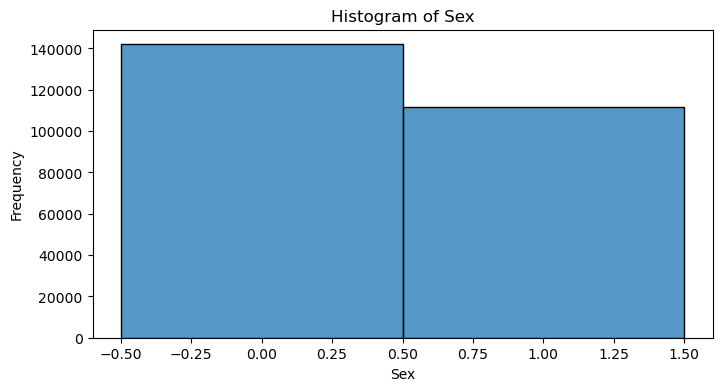

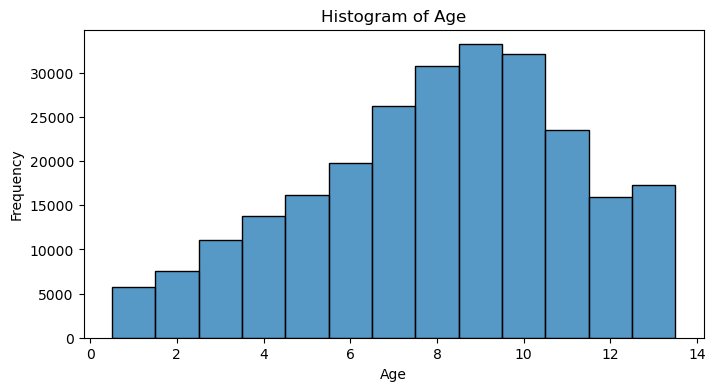

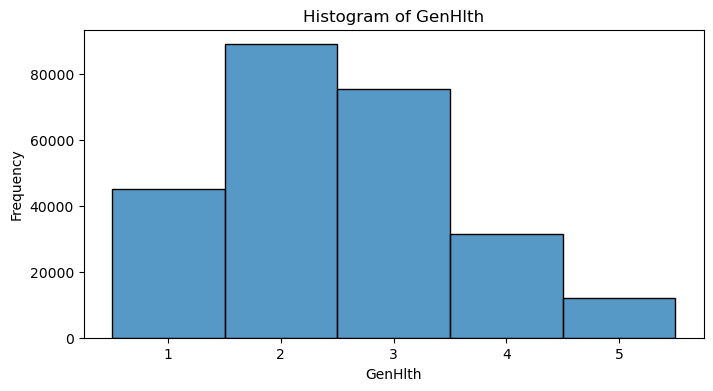

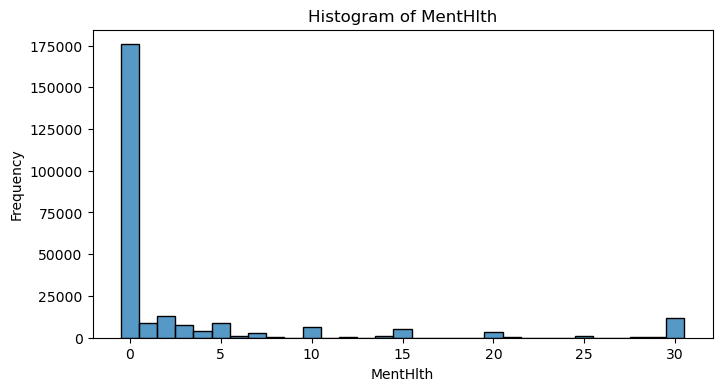

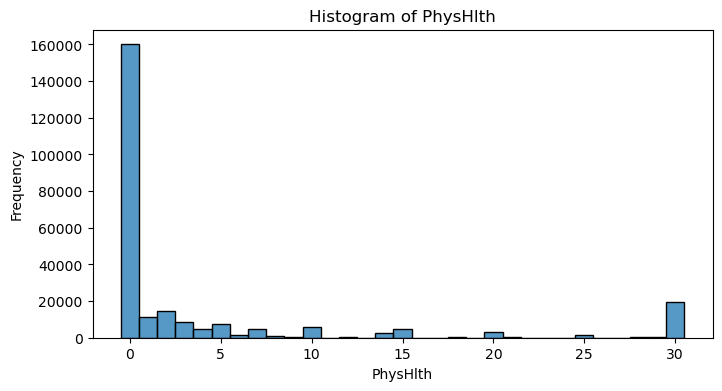

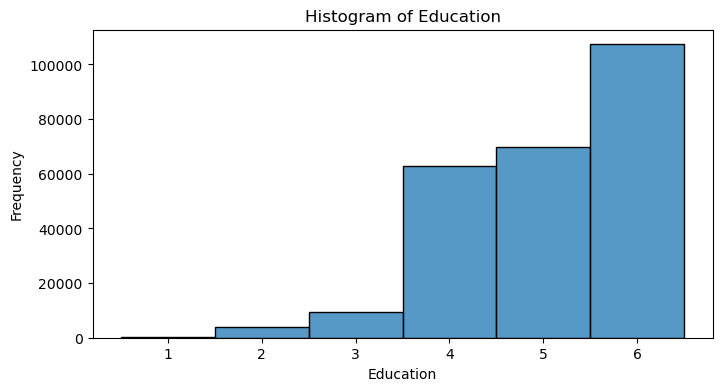

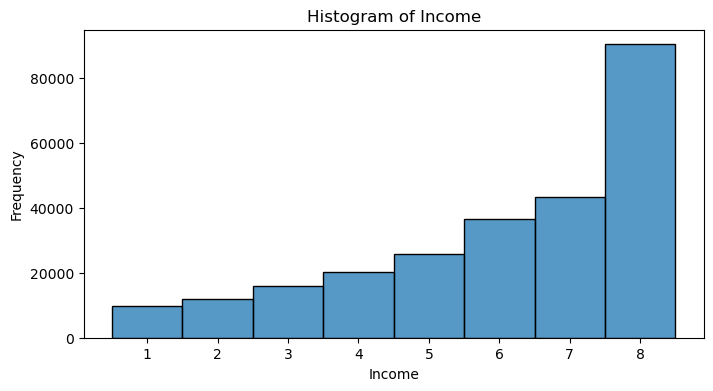

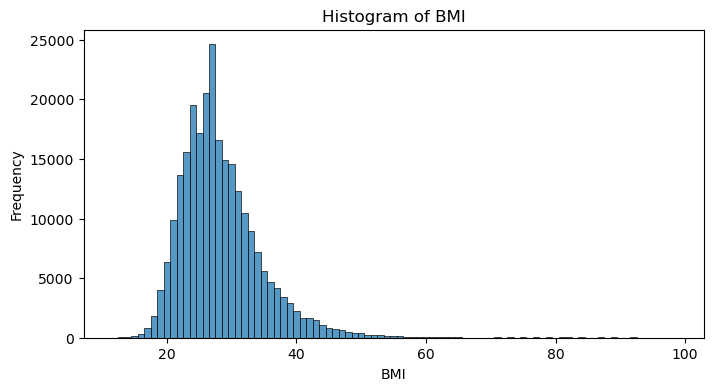

In [55]:
nominal_vars = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', "Age"]

ordinal_vars = ['GenHlth', 'MentHlth', 'PhysHlth', 'Education', 'Income', "BMI"]

for var in nominal_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_diabetes_012[var], kde=False, discrete=True)
    plt.title(f'Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

for var in ordinal_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_diabetes_012[var], kde=False, discrete=True)
    plt.title(f'Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

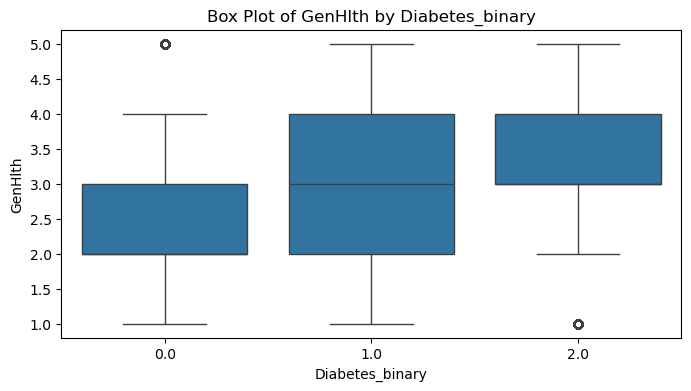

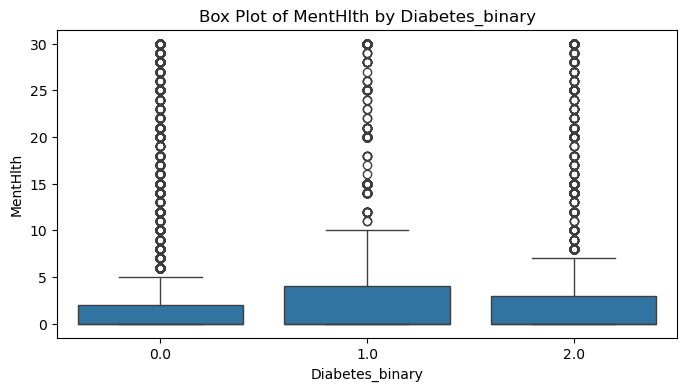

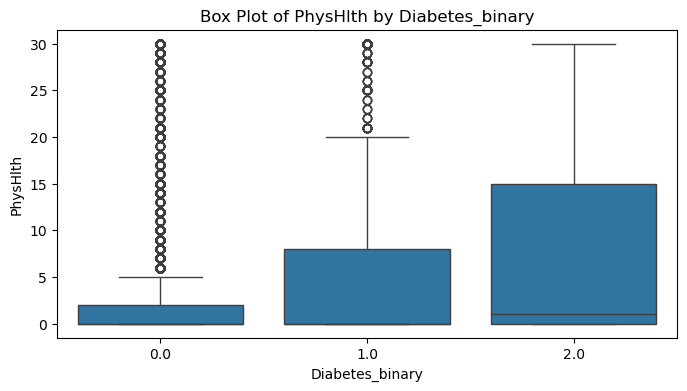

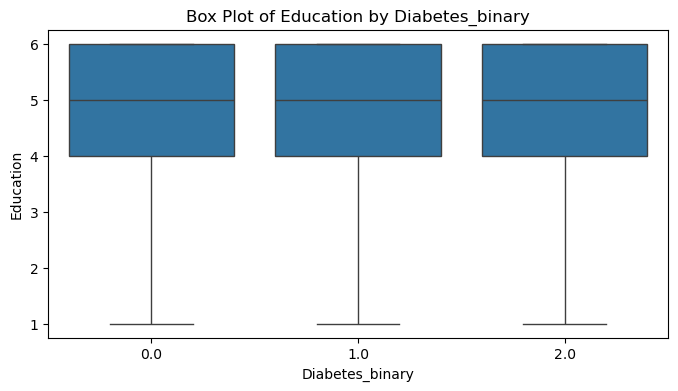

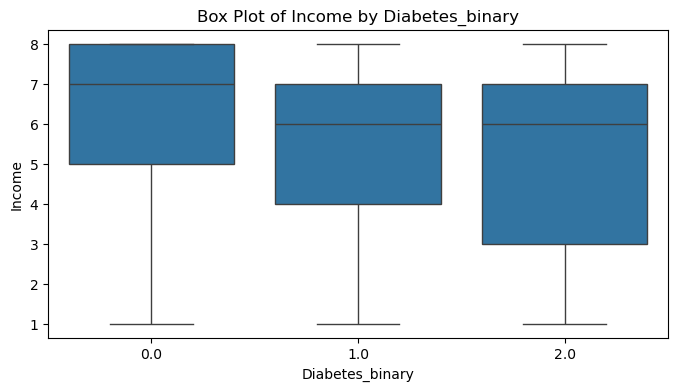

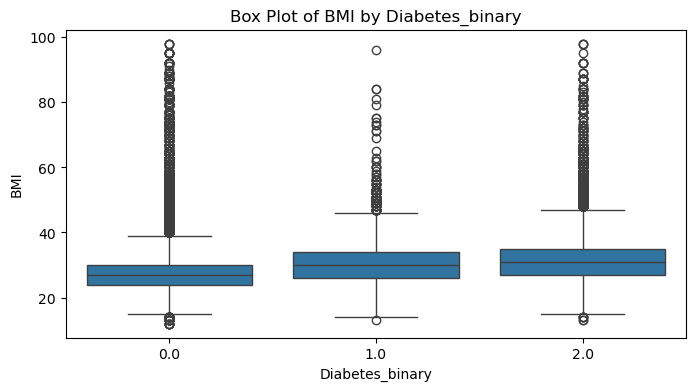

In [56]:
# Box Plots for numerical variables
for var in ordinal_vars:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Diabetes_012', y=var, data=df_diabetes_012)
    plt.title(f'Box Plot of {var} by Diabetes_binary')
    plt.xlabel('Diabetes_binary')
    plt.ylabel(var)
    plt.show()


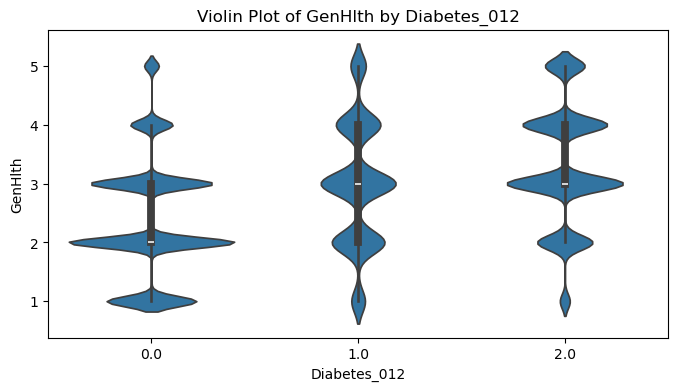

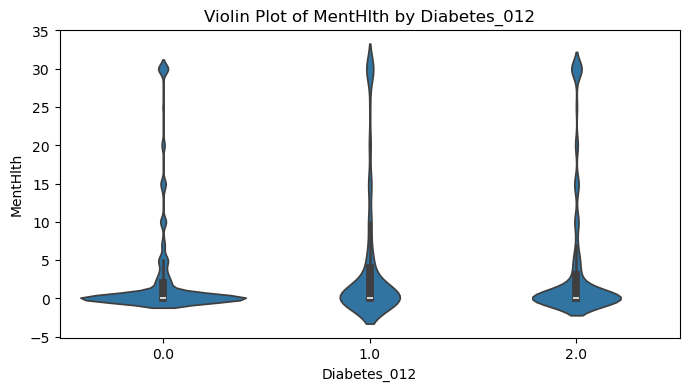

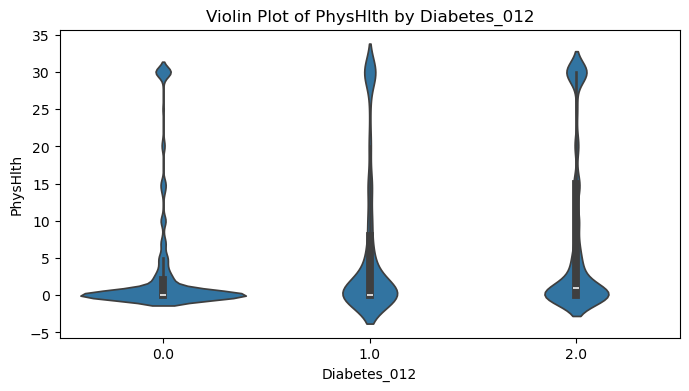

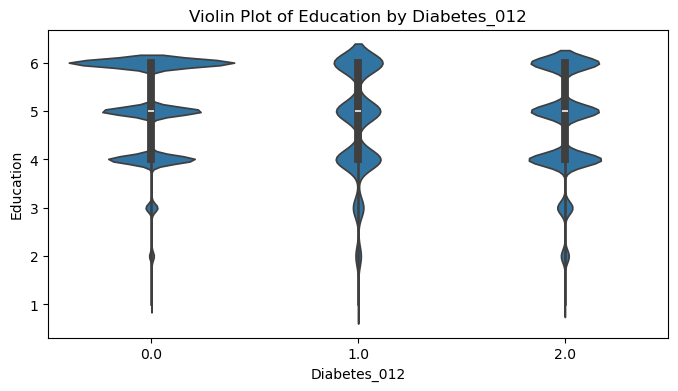

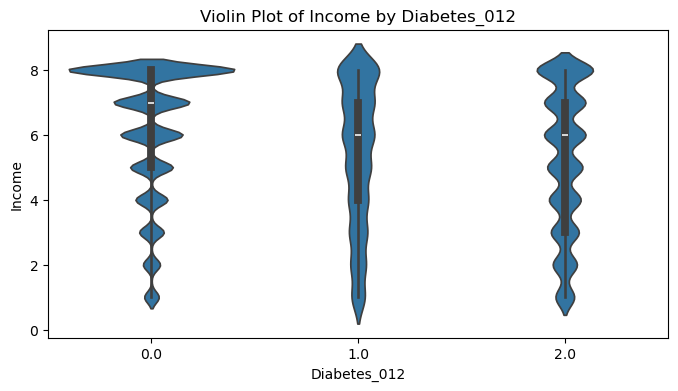

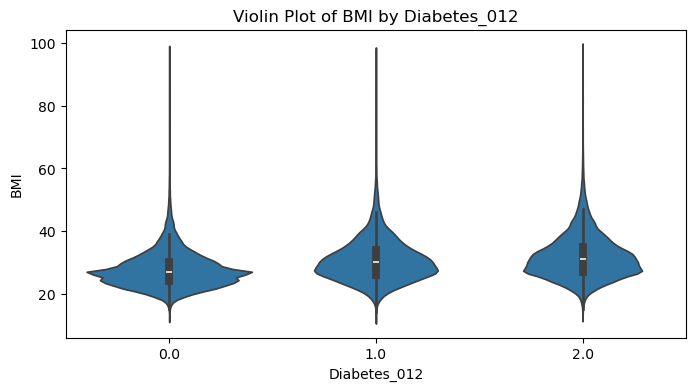

In [57]:
# Violin Plots for numerical variables
for var in ordinal_vars:
    plt.figure(figsize=(8, 4))
    sns.violinplot(x='Diabetes_012', y=var, data=df_diabetes_012)
    plt.title(f'Violin Plot of {var} by Diabetes_012')
    plt.xlabel('Diabetes_012')
    plt.ylabel(var)
    plt.show()

## Korrelationsmatrix

Die Korrelationsmatrix zeigt die Korrelationen zwischen verschiedenen Gesundheitsindikatoren im Datensatz `df_diabetes_012`. Eine Korrelation gibt an, wie stark zwei Variablen miteinander zusammenhängen. Die Werte reichen von -1 bis 1, wobei -1 eine perfekte negative Korrelation, 0 keine Korrelation und 1 eine perfekte positive Korrelation darstellt.

### Visualisierung der Korrelationsmatrix

Um die Korrelationen besser zu verstehen, haben wir eine Heatmap der Korrelationsmatrix erstellt. In dieser Heatmap sind die Korrelationen farblich dargestellt, wobei stärkere Korrelationen durch intensivere Farben hervorgehoben werden.

### Interpretation der Korrelationsmatrix

Einige wichtige Beobachtungen aus der Korrelationsmatrix sind:

- **Diabetes_012** zeigt eine moderate positive Korrelation mit **GenHlth** (0.30) und **Age** (0.19).
- **HighBP** (Bluthochdruck) korreliert stark mit **Age** (0.34) und **GenHlth** (0.30).
- **PhysActivity** (körperliche Aktivität) zeigt eine moderate negative Korrelation mit **GenHlth** (-0.27) und **DiffWalk** (-0.25).

Diese Korrelationen können Hinweise auf mögliche Zusammenhänge zwischen verschiedenen Gesundheitsindikatoren und Diabetes liefern und helfen, weitere Analysen und Hypothesen zu entwickeln.

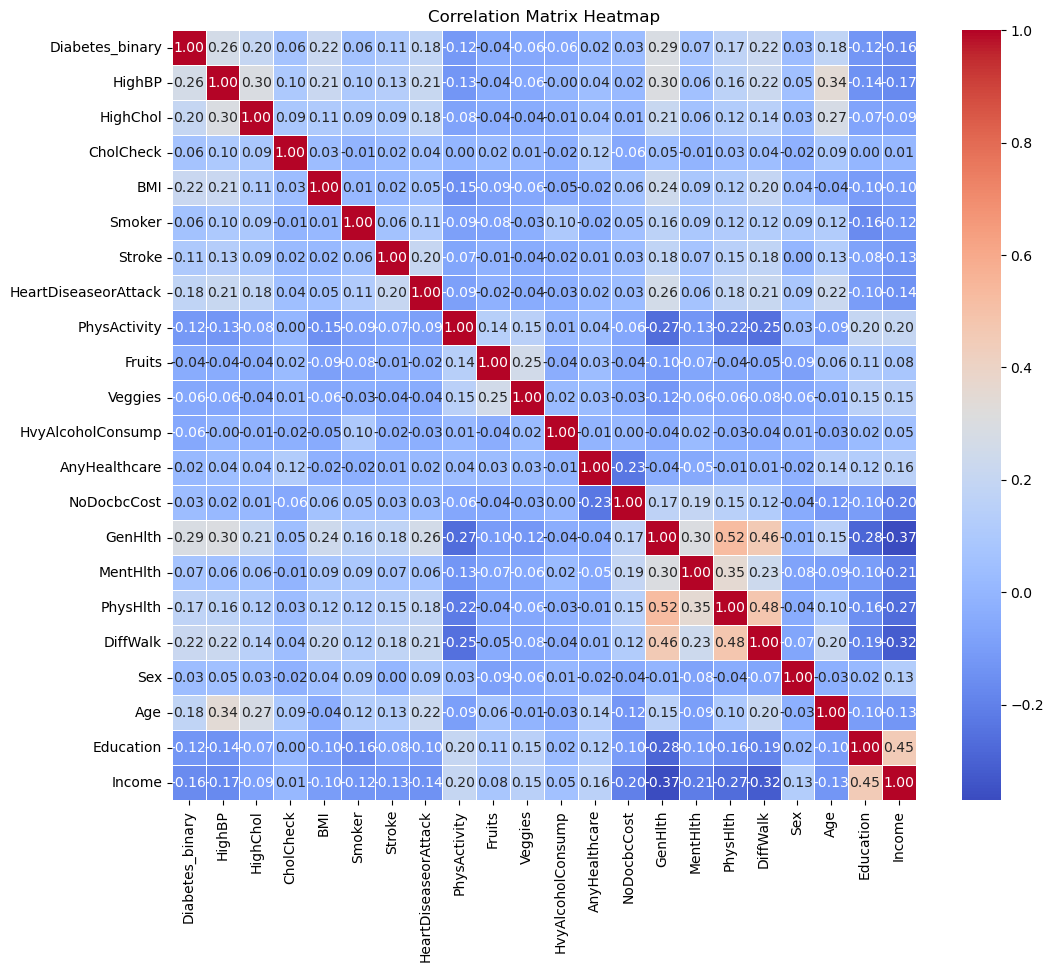

In [80]:
correlation_matrix = df_diabetes_binary.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

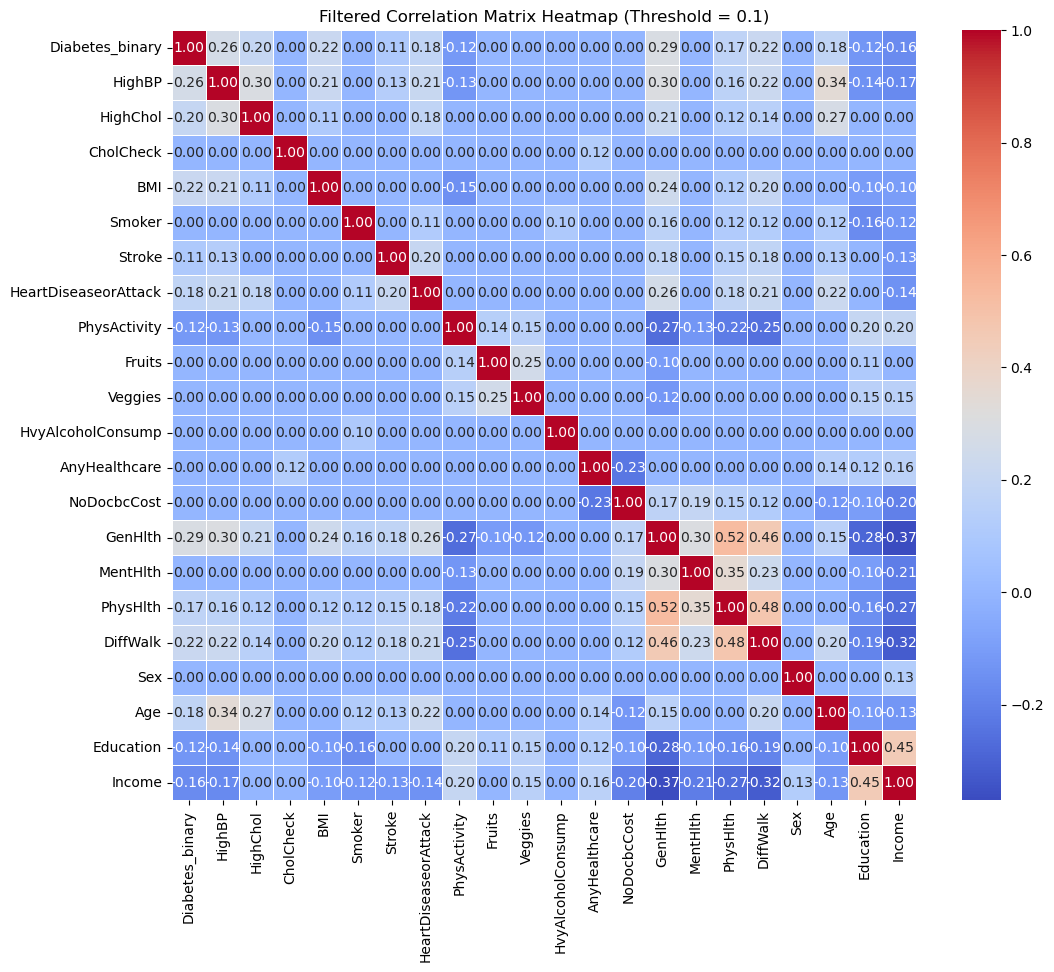

In [81]:
# Set the threshold
threshold = 0.1

# Filter the correlation matrix
filtered_correlation_matrix = correlation_matrix.copy()
filtered_correlation_matrix[abs(filtered_correlation_matrix) < threshold] = 0

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(filtered_correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Filtered Correlation Matrix Heatmap (Threshold = 0.1)')
plt.show()

# Data Preperation & Feature Enginerring

In [60]:
df_diabetes_binary_cleaned = df_diabetes_binary.drop(["Smoker", "Fruits", "Veggies", "HvyAlcoholConsump", "NoDocbcCost", "MentHlth", "Sex"], axis=1)
df_diabetes_binary_50_50_cleaned = df_diabetes_binary_50_50.drop(["Smoker", "Fruits", "Veggies", "HvyAlcoholConsump", "NoDocbcCost", "MentHlth", "Sex"], axis=1)

## Traning & Testdaten spliten


### df_diabetes_binary

In [61]:
# Define the features and target variable
X_binary = df_diabetes_binary_cleaned.drop('Diabetes_binary', axis=1)
y_binary = df_diabetes_binary_cleaned['Diabetes_binary']

# Split the data into training and testing sets
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(X_binary, y_binary, test_size=0.2, random_state=42)

display(f"Training data shape: {X_train_binary.shape}")
display(f"Testing data shape: {X_test_binary.shape}")

'Training data shape: (202944, 14)'

'Testing data shape: (50736, 14)'

### df_diabetes_binary_50_50

In [62]:
# Define the features and target variable
X_50_50 = df_diabetes_binary_50_50_cleaned.drop('Diabetes_binary', axis=1)
y_50_50 = df_diabetes_binary_50_50_cleaned['Diabetes_binary']

# Split the data into training and testing sets
X_train_50_50, X_test_50_50, y_train_50_50, y_test_50_50 = train_test_split(X_50_50, y_50_50, test_size=0.2, random_state=42)

display(f"Training data shape: {X_train_50_50.shape}")
display(f"Testing data shape: {X_test_50_50.shape}")

'Training data shape: (56553, 14)'

'Testing data shape: (14139, 14)'

# Modeling


🔍 Training models for: df_diabetes_binary

➡️ Grid Search: Logistic Regression
✅ Best parameters: {'C': 0.1, 'max_iter': 100}
✅ CV Accuracy: 0.8629

📊 Training Report:
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.92    174595
         1.0       0.53      0.14      0.23     28349

    accuracy                           0.86    202944
   macro avg       0.70      0.56      0.58    202944
weighted avg       0.83      0.86      0.83    202944

Training Confusion Matrix:


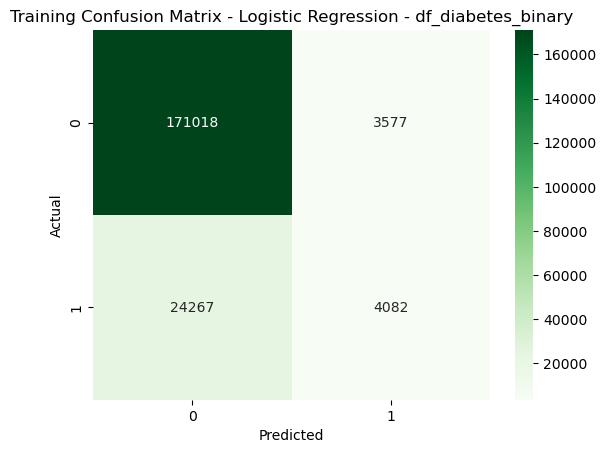

📊 Test Report:
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93     43739
         1.0       0.54      0.15      0.24      6997

    accuracy                           0.87     50736
   macro avg       0.71      0.57      0.58     50736
weighted avg       0.83      0.87      0.83     50736

Test Confusion Matrix:


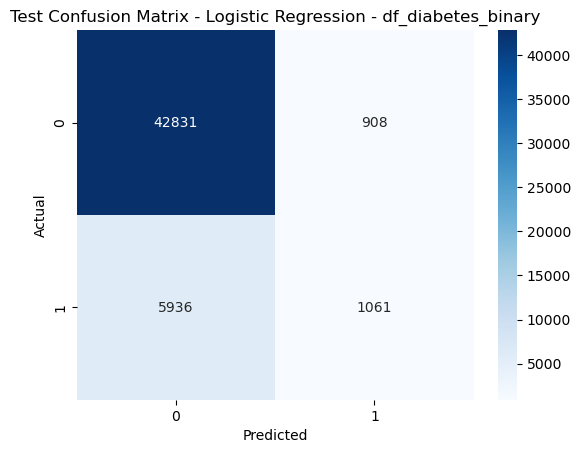

➡️ Grid Search: Decision Tree
✅ Best parameters: {'max_depth': 5, 'min_samples_split': 2}
✅ CV Accuracy: 0.8643

📊 Training Report:
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.93    174595
         1.0       0.60      0.09      0.16     28349

    accuracy                           0.86    202944
   macro avg       0.73      0.54      0.54    202944
weighted avg       0.83      0.86      0.82    202944

Training Confusion Matrix:


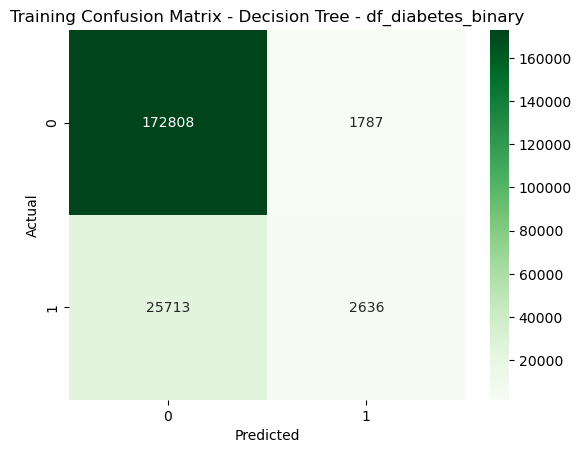

📊 Test Report:
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.93     43739
         1.0       0.59      0.10      0.17      6997

    accuracy                           0.87     50736
   macro avg       0.73      0.54      0.55     50736
weighted avg       0.83      0.87      0.82     50736

Test Confusion Matrix:


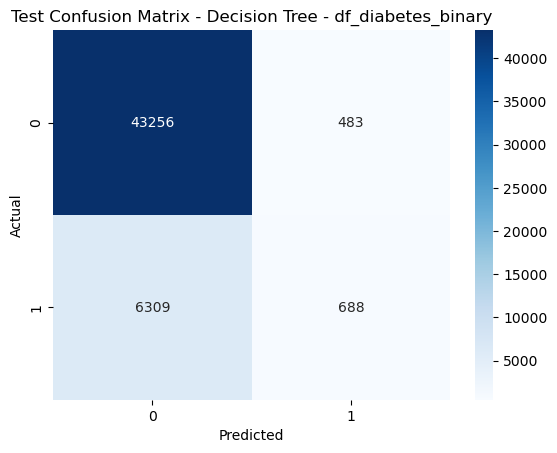

➡️ Grid Search: KNN
✅ Best parameters: {'n_neighbors': 9, 'weights': 'uniform'}
✅ CV Accuracy: 0.8555

📊 Training Report:
              precision    recall  f1-score   support

         0.0       0.89      0.98      0.93    174595
         1.0       0.64      0.24      0.35     28349

    accuracy                           0.87    202944
   macro avg       0.76      0.61      0.64    202944
weighted avg       0.85      0.87      0.85    202944

Training Confusion Matrix:


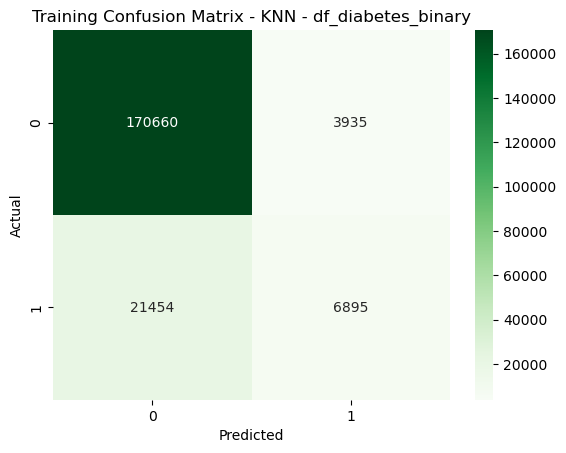

📊 Test Report:
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     43739
         1.0       0.44      0.17      0.24      6997

    accuracy                           0.86     50736
   macro avg       0.66      0.57      0.58     50736
weighted avg       0.82      0.86      0.83     50736

Test Confusion Matrix:


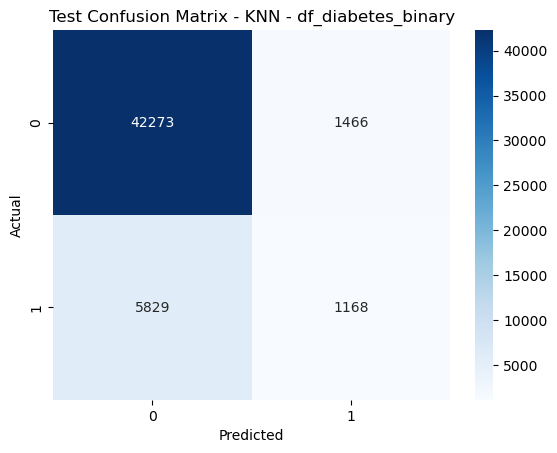

➡️ Grid Search: Random Forest
✅ Best parameters: {'max_depth': 10, 'n_estimators': 100}
✅ CV Accuracy: 0.8654

📊 Training Report:
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.93    174595
         1.0       0.67      0.11      0.19     28349

    accuracy                           0.87    202944
   macro avg       0.77      0.55      0.56    202944
weighted avg       0.84      0.87      0.83    202944

Training Confusion Matrix:


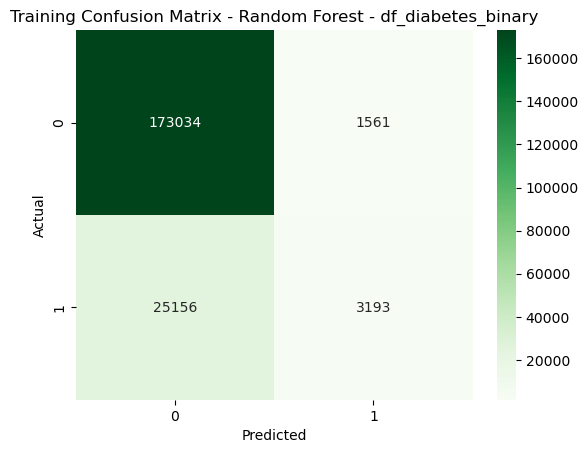

📊 Test Report:
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.93     43739
         1.0       0.59      0.10      0.17      6997

    accuracy                           0.87     50736
   macro avg       0.73      0.54      0.55     50736
weighted avg       0.83      0.87      0.82     50736

Test Confusion Matrix:


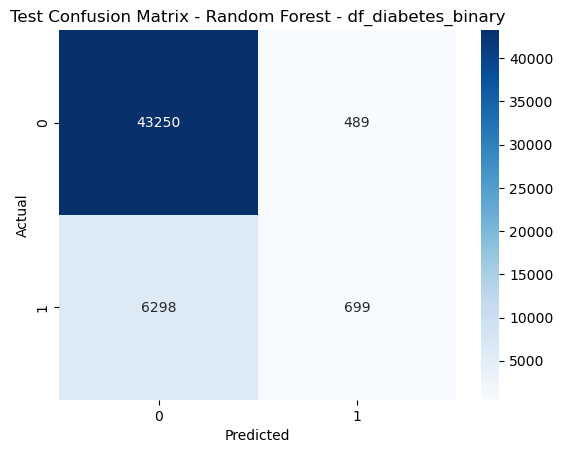


🔍 Training models for: df_diabetes_binary_50_50

➡️ Grid Search: Logistic Regression
✅ Best parameters: {'C': 10, 'max_iter': 100}
✅ CV Accuracy: 0.7460

📊 Training Report:
              precision    recall  f1-score   support

         0.0       0.76      0.73      0.74     28256
         1.0       0.74      0.77      0.75     28297

    accuracy                           0.75     56553
   macro avg       0.75      0.75      0.75     56553
weighted avg       0.75      0.75      0.75     56553

Training Confusion Matrix:


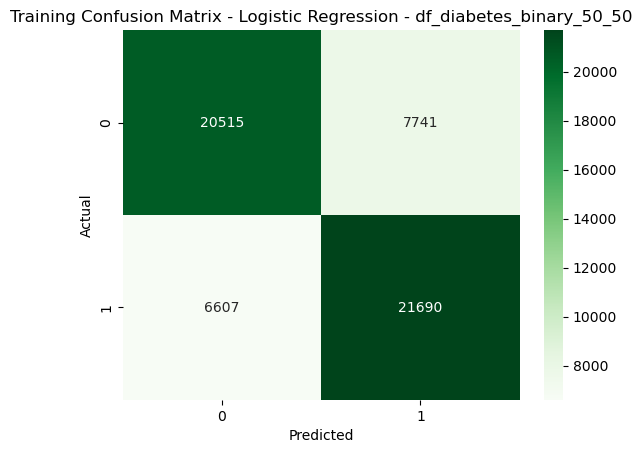

📊 Test Report:
              precision    recall  f1-score   support

         0.0       0.76      0.73      0.74      7090
         1.0       0.74      0.76      0.75      7049

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139

Test Confusion Matrix:


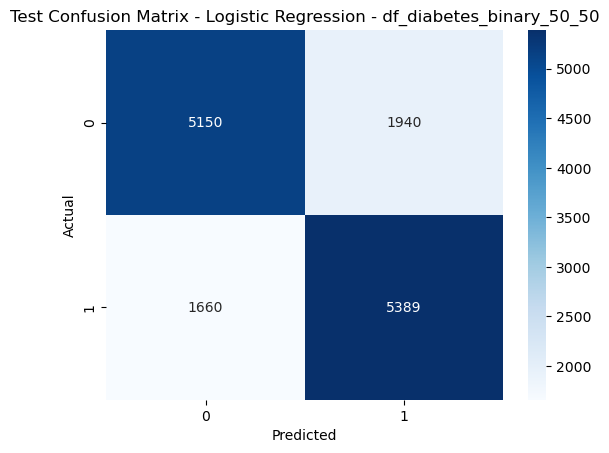

➡️ Grid Search: Decision Tree
✅ Best parameters: {'max_depth': 10, 'min_samples_split': 10}
✅ CV Accuracy: 0.7322

📊 Training Report:
              precision    recall  f1-score   support

         0.0       0.79      0.73      0.76     28256
         1.0       0.75      0.80      0.77     28297

    accuracy                           0.77     56553
   macro avg       0.77      0.77      0.76     56553
weighted avg       0.77      0.77      0.76     56553

Training Confusion Matrix:


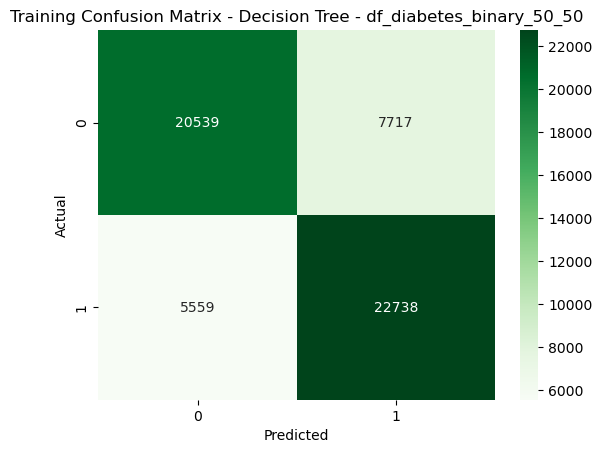

📊 Test Report:
              precision    recall  f1-score   support

         0.0       0.76      0.69      0.72      7090
         1.0       0.71      0.78      0.74      7049

    accuracy                           0.73     14139
   macro avg       0.74      0.73      0.73     14139
weighted avg       0.74      0.73      0.73     14139

Test Confusion Matrix:


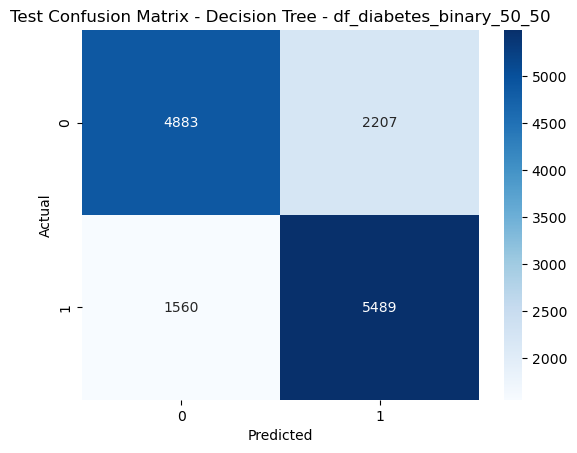

➡️ Grid Search: KNN
✅ Best parameters: {'n_neighbors': 9, 'weights': 'uniform'}
✅ CV Accuracy: 0.7191

📊 Training Report:
              precision    recall  f1-score   support

         0.0       0.79      0.74      0.76     28256
         1.0       0.76      0.80      0.78     28297

    accuracy                           0.77     56553
   macro avg       0.77      0.77      0.77     56553
weighted avg       0.77      0.77      0.77     56553

Training Confusion Matrix:


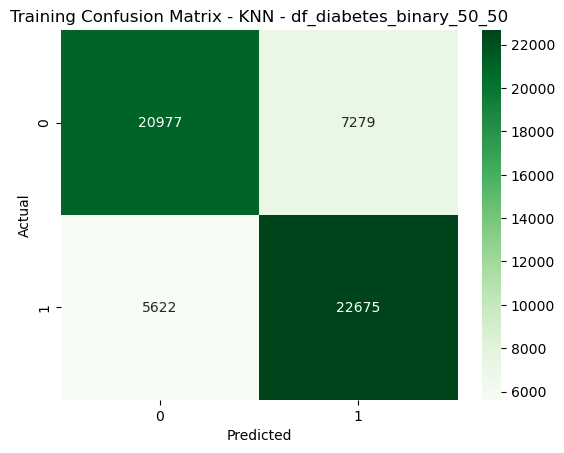

📊 Test Report:
              precision    recall  f1-score   support

         0.0       0.74      0.69      0.71      7090
         1.0       0.71      0.75      0.73      7049

    accuracy                           0.72     14139
   macro avg       0.72      0.72      0.72     14139
weighted avg       0.72      0.72      0.72     14139

Test Confusion Matrix:


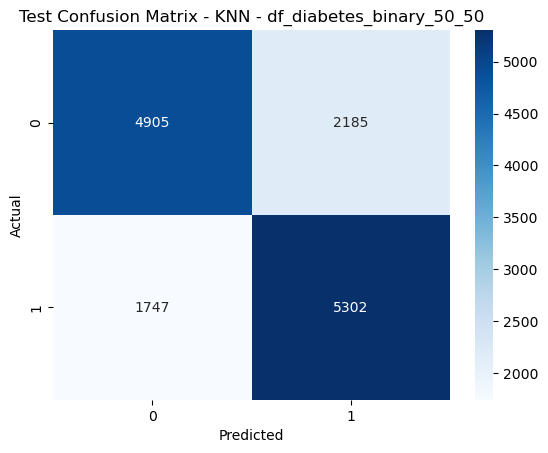

➡️ Grid Search: Random Forest
✅ Best parameters: {'max_depth': 10, 'n_estimators': 100}
✅ CV Accuracy: 0.7494

📊 Training Report:
              precision    recall  f1-score   support

         0.0       0.79      0.73      0.76     28256
         1.0       0.75      0.81      0.78     28297

    accuracy                           0.77     56553
   macro avg       0.77      0.77      0.77     56553
weighted avg       0.77      0.77      0.77     56553

Training Confusion Matrix:


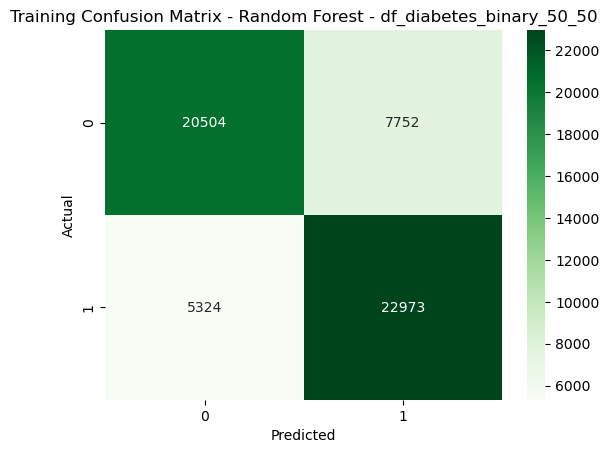

📊 Test Report:
              precision    recall  f1-score   support

         0.0       0.78      0.70      0.74      7090
         1.0       0.73      0.79      0.76      7049

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139

Test Confusion Matrix:


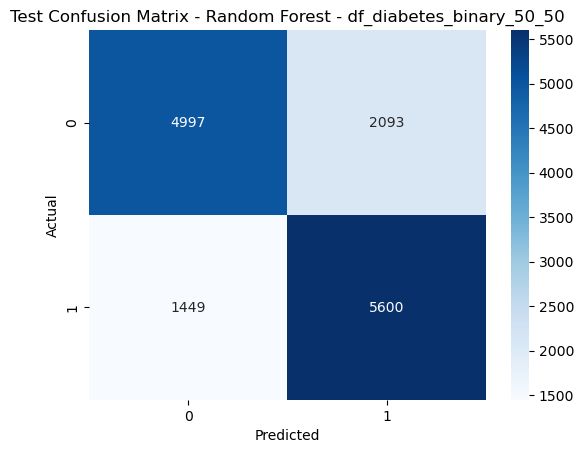


🔥 Best Model Overall:
Model                                      Random Forest
Dataset                         df_diabetes_binary_50_50
CV Accuracy                                     0.749421
Train Accuracy                                  0.768783
Test Accuracy                                   0.749487
Train F1                                        0.778455
Test F1                                         0.759734
Best Params       {'max_depth': 10, 'n_estimators': 100}
Name: 7, dtype: object

📊 Comparison of all models:


,Model,Dataset,CV Accuracy,Train Accuracy,Test Accuracy,Train F1,Test F1,Best Params
7,Random Forest,df_diabetes_binary_50_50,0.749421,0.768783,0.749487,0.778455,0.759734,"{'max_depth': 10, 'n_estimators': 100}"
4,Logistic Regression,df_diabetes_binary_50_50,0.746008,0.746291,0.745385,0.751455,0.749617,"{'C': 10, 'max_iter': 100}"
5,Decision Tree,df_diabetes_binary_50_50,0.732163,0.765247,0.733574,0.774033,0.744524,"{'max_depth': 10, 'min_samples_split': 10}"
6,KNN,df_diabetes_binary_50_50,0.719131,0.771878,0.721904,0.778527,0.729499,"{'n_neighbors': 9, 'weights': 'uniform'}"
2,KNN,df_diabetes_binary,0.855453,0.874897,0.856216,0.351974,0.242550,"{'n_neighbors': 9, 'weights': 'uniform'}"
0,Logistic Regression,df_diabetes_binary,0.862888,0.862800,0.865106,0.226727,0.236672,"{'C': 0.1, 'max_iter': 100}"
3,Random Forest,df_diabetes_binary,0.865431,0.868353,0.866229,0.192913,0.170800,"{'max_depth': 10, 'n_estimators': 100}"
1,Decision Tree,df_diabetes_binary,0.864317,0.864495,0.866131,0.160869,0.168462,"{'max_depth': 5, 'min_samples_split': 2}"


In [63]:
# Modelle definieren
models = {
    "Logistic Regression": LogisticRegression(solver='liblinear'),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier()
}

param_grids = {
    "Logistic Regression": {'C': [0.01, 0.1, 1, 10, 100], 'max_iter': [100, 500, 1000]},
    "Decision Tree": {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]},
    "KNN": {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']},
    "Random Forest": {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 10, None]},
}
datasets = {
    "df_diabetes_binary": (X_train_binary, y_train_binary, X_test_binary, y_test_binary),
    "df_diabetes_binary_50_50": (X_train_50_50, y_train_50_50, X_test_50_50, y_test_50_50)
}

model_results = []

# Trainings-Loop
for dataset_name, (X_train, y_train, X_test, y_test) in datasets.items():
    print(f"\n🔍 Training models for: {dataset_name}\n")

    # Iteriere über alle Modelle
    for model_name, model in models.items():
        if model_name not in param_grids:
            print(f"⚠️ No param grid for {model_name}, skipping.")
            continue

        print(f"➡️ Grid Search: {model_name}")
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grids[model_name],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        y_pred_train = best_model.predict(X_train)
        y_pred_test = best_model.predict(X_test)

        print(f"✅ Best parameters: {grid.best_params_}")
        print(f"✅ CV Accuracy: {grid.best_score_:.4f}")

        # Evaluation
        train_accuracy = accuracy_score(y_train, y_pred_train)
        test_accuracy = accuracy_score(y_test, y_pred_test)
        train_f1 = f1_score(y_train, y_pred_train)
        test_f1 = f1_score(y_test, y_pred_test)

        model_results.append({
            "Model": model_name,
            "Dataset": dataset_name,
            "CV Accuracy": grid.best_score_,
            "Train Accuracy": train_accuracy,
            "Test Accuracy": test_accuracy,
            "Train F1": train_f1,
            "Test F1": test_f1,
            "Best Params": grid.best_params_
        })

        # Trainingsauswertung
        print("\n📊 Training Report:")
        print(classification_report(y_train, y_pred_train))

        print("Training Confusion Matrix:")
        sns.heatmap(confusion_matrix(y_train, y_pred_train), annot=True, fmt='d', cmap='Greens')
        plt.title(f'Training Confusion Matrix - {model_name} - {dataset_name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

        # Testauswertung
        print("📊 Test Report:")
        print(classification_report(y_test, y_pred_test))

        print("Test Confusion Matrix:")
        sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d', cmap='Blues')
        plt.title(f'Test Confusion Matrix - {model_name} - {dataset_name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

results_df = pd.DataFrame(model_results)


# Feature Importance

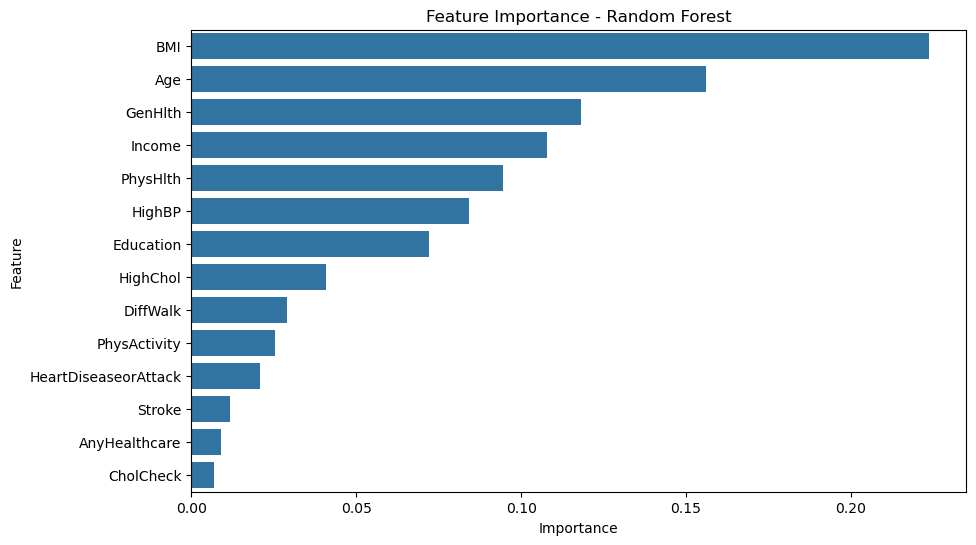

In [64]:
# Fit the Random Forest model if not already fitted
if not hasattr(model, "feature_importances_"):
    X_train, y_train = datasets[dataset_name][:2]  # Extract training data
    model.fit(X_train, y_train)

# Extract the feature importance from the Random Forest model
feature_importances = model.feature_importances_

# Get the feature names from the dataset
feature_names = datasets[dataset_name][0].columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Display the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Evaluation

In [68]:
print("\n📊 Comparison of all models:")
display(results_df.sort_values(by="Test F1", ascending=False))


📊 Comparison of all models:


,Model,Dataset,CV Accuracy,Train Accuracy,Test Accuracy,Train F1,Test F1,Best Params
7,Random Forest,df_diabetes_binary_50_50,0.749421,0.768783,0.749487,0.778455,0.759734,"{'max_depth': 10, 'n_estimators': 100}"
4,Logistic Regression,df_diabetes_binary_50_50,0.746008,0.746291,0.745385,0.751455,0.749617,"{'C': 10, 'max_iter': 100}"
5,Decision Tree,df_diabetes_binary_50_50,0.732163,0.765247,0.733574,0.774033,0.744524,"{'max_depth': 10, 'min_samples_split': 10}"
6,KNN,df_diabetes_binary_50_50,0.719131,0.771878,0.721904,0.778527,0.729499,"{'n_neighbors': 9, 'weights': 'uniform'}"
2,KNN,df_diabetes_binary,0.855453,0.874897,0.856216,0.351974,0.242550,"{'n_neighbors': 9, 'weights': 'uniform'}"
0,Logistic Regression,df_diabetes_binary,0.862888,0.862800,0.865106,0.226727,0.236672,"{'C': 0.1, 'max_iter': 100}"
3,Random Forest,df_diabetes_binary,0.865431,0.868353,0.866229,0.192913,0.170800,"{'max_depth': 10, 'n_estimators': 100}"
1,Decision Tree,df_diabetes_binary,0.864317,0.864495,0.866131,0.160869,0.168462,"{'max_depth': 5, 'min_samples_split': 2}"


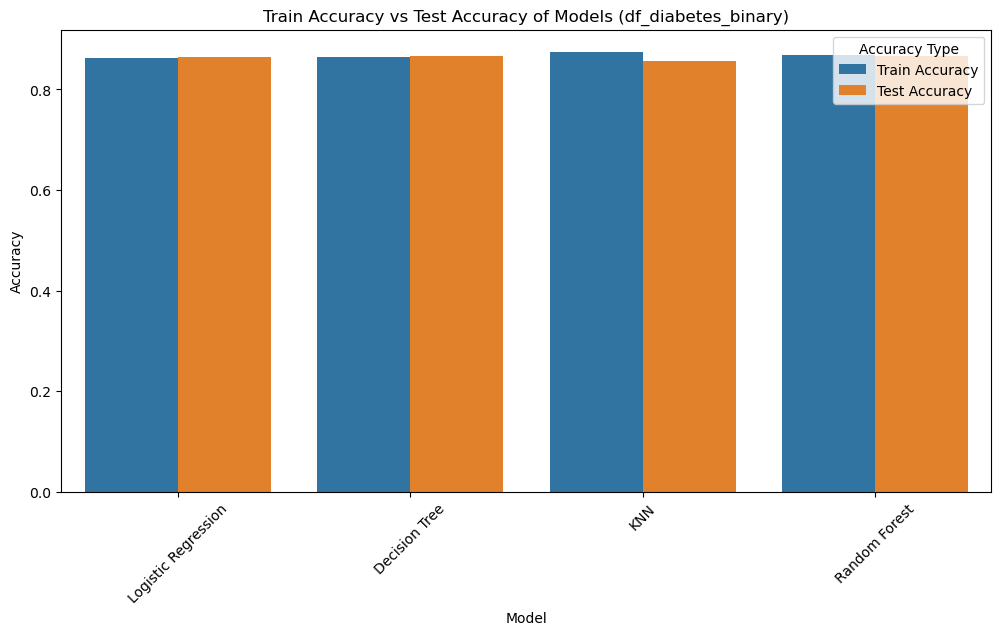

In [71]:
# Filter results for df_diabetes_binary
binary_results_df = results_df[results_df["Dataset"] == "df_diabetes_binary"]

# Visualize Train Accuracy vs Test Accuracy for df_diabetes_binary
plt.figure(figsize=(12, 6))
accuracy_df = binary_results_df.melt(id_vars=["Model"], value_vars=["Train Accuracy", "Test Accuracy"], 
                                     var_name="Accuracy Type", value_name="Accuracy")
sns.barplot(data=accuracy_df, x="Model", y="Accuracy", hue="Accuracy Type")
plt.title("Train Accuracy vs Test Accuracy of Models (df_diabetes_binary)")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.legend(title="Accuracy Type")
plt.xticks(rotation=45)
plt.show()


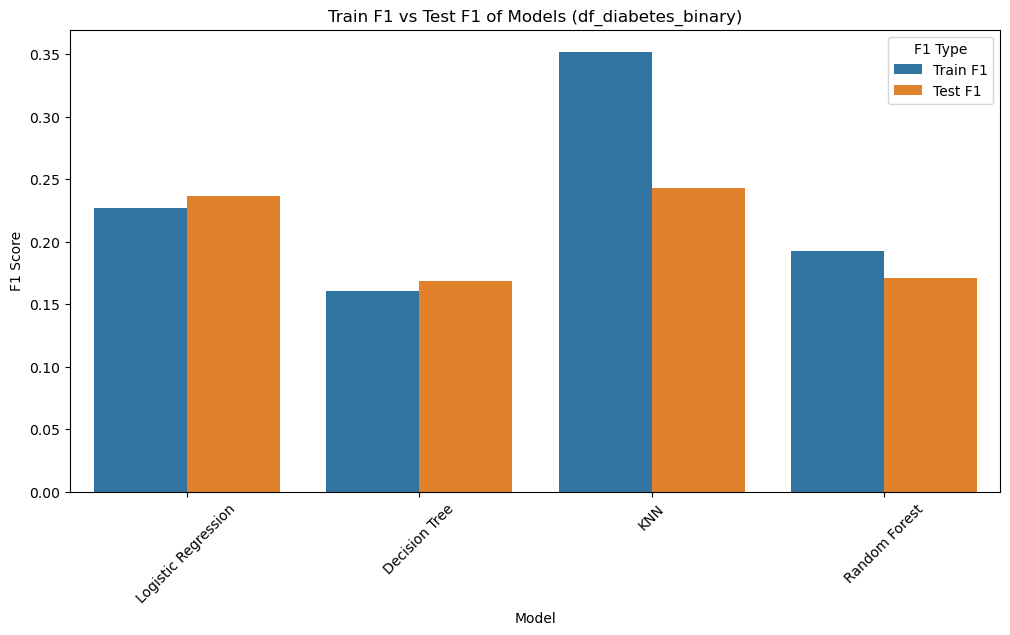

In [72]:
# Filter results for df_diabetes_binary
binary_results_df = results_df[results_df["Dataset"] == "df_diabetes_binary"]

# Visualize Train F1 vs Test F1 for df_diabetes_binary
plt.figure(figsize=(12, 6))
f1_df = binary_results_df.melt(id_vars=["Model"], value_vars=["Train F1", "Test F1"], 
                               var_name="F1 Type", value_name="F1 Score")
sns.barplot(data=f1_df, x="Model", y="F1 Score", hue="F1 Type")
plt.title("Train F1 vs Test F1 of Models (df_diabetes_binary)")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.legend(title="F1 Type")
plt.xticks(rotation=45)
plt.show()

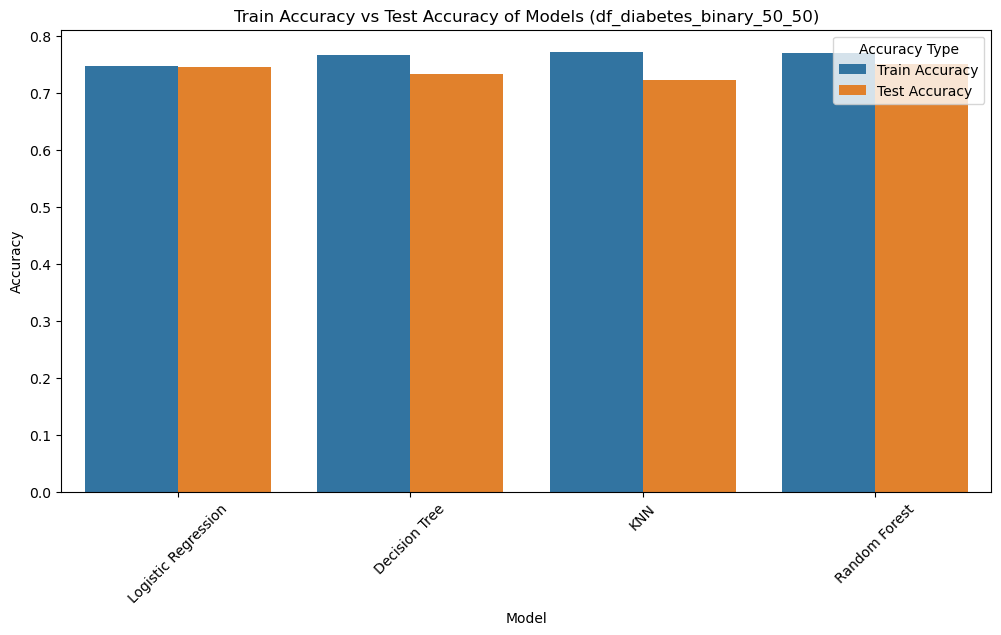

In [79]:
# Filter results for df_diabetes_binary
binary_50_50_results_df = results_df[results_df["Dataset"] == "df_diabetes_binary_50_50"]

# Visualize Train Accuracy vs Test Accuracy for df_diabetes_binary
plt.figure(figsize=(12, 6))
accuracy_df = binary_50_50_results_df.melt(id_vars=["Model"], value_vars=["Train Accuracy", "Test Accuracy"], 
                                     var_name="Accuracy Type", value_name="Accuracy")
sns.barplot(data=accuracy_df, x="Model", y="Accuracy", hue="Accuracy Type")
plt.title("Train Accuracy vs Test Accuracy of Models (df_diabetes_binary_50_50)")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.legend(title="Accuracy Type")
plt.xticks(rotation=45)
plt.show()


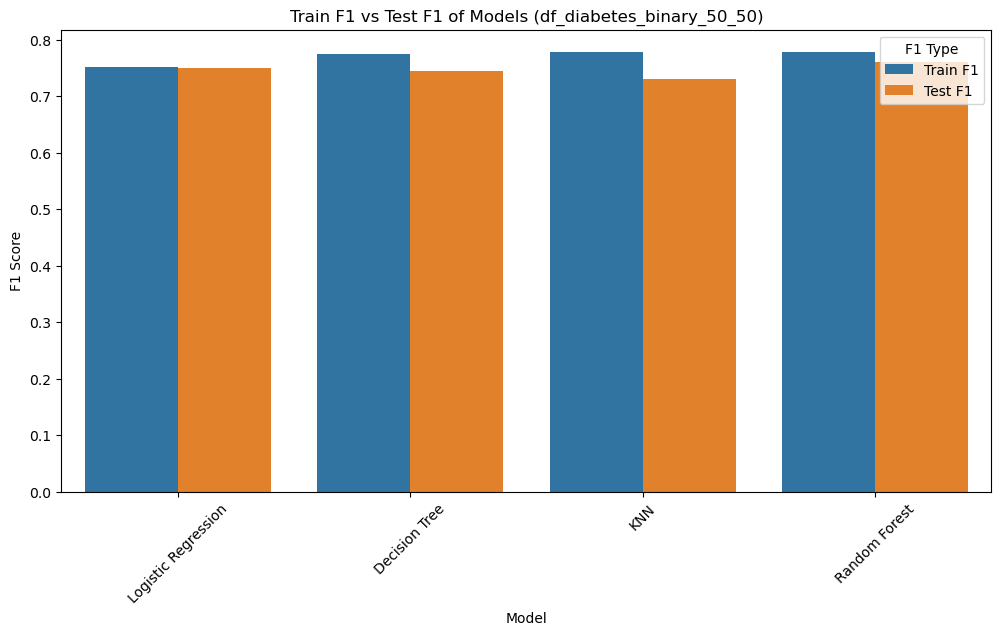

In [78]:
# Filter results for df_diabetes_binary
binary_50_50_results_df = results_df[results_df["Dataset"] == "df_diabetes_binary_50_50"]

# Visualize Train F1 vs Test F1 for df_diabetes_binary
plt.figure(figsize=(12, 6))
f1_df = binary_50_50_results_df.melt(id_vars=["Model"], value_vars=["Train F1", "Test F1"], 
                               var_name="F1 Type", value_name="F1 Score")
sns.barplot(data=f1_df, x="Model", y="F1 Score", hue="F1 Type")
plt.title("Train F1 vs Test F1 of Models (df_diabetes_binary_50_50)")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.legend(title="F1 Type")
plt.xticks(rotation=45)
plt.show()